# Loading the MNIST dataset

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

In [4]:
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [5]:
print(y)

[5 0 4 ... 4 5 6]


In [6]:
print(X.shape)

(70000, 784)


In [7]:
print(y.shape)

(70000,)


## Normalizing the MNIST Pixel Values from [0, 255] to [-1, 1]

In [8]:
X = ((X/255.0) - 0.5) * 2

# Visualizing the MNIST Digits

In [9]:
import matplotlib.pyplot as plt

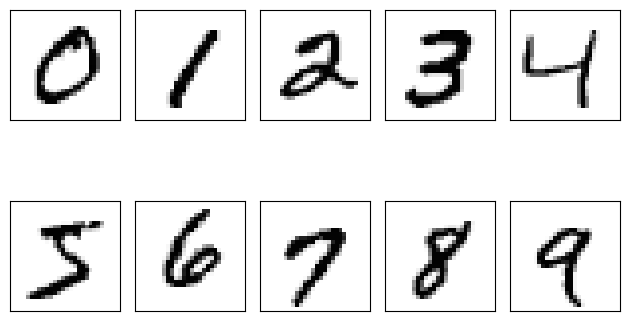

In [10]:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
  img = X[y == i][0].reshape(28, 28)
  ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

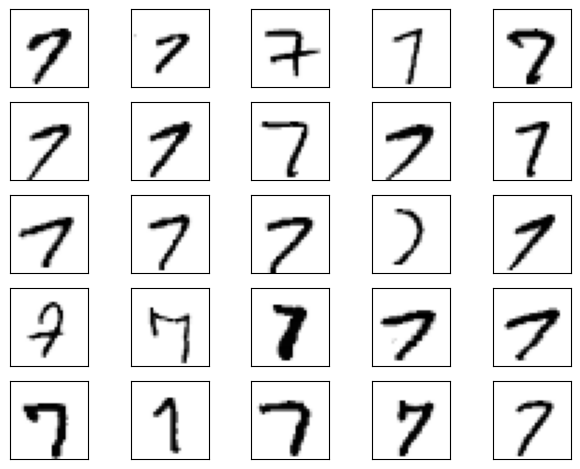

In [11]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
  img = X[y == 7][i].reshape(28, 28)
  ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

# Splitting MNIST into Training, Validation, and Test Sets

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# 60k temporary training examples + 10k test examples
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

# 55k training examples + 5k validation examples
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=5000, random_state=123, stratify=y)

# Implementing MLP Class

In [14]:
import numpy as np

## Defining the Helper Functions

In [15]:
def sigmoid(z):
  """Sigmoid activation"""
  return 1.0 / (1.0 + np.exp(-z))

def int_to_onehot(y, num_labels):
  """Integer Labels -> One-Hot Encoding"""
  ary = np.zeros((y.shape[0], num_labels))
  for i, val in enumerate(y):
    ary[i, val] = 1
  return ary

0 → [1,0,0,0,0,0,0,0,0,0]

2 → [0,0,1,0,0,0,0,0,0,0]

9 → [0,0,0,0,0,0,0,0,0,1]

## NeuralNetMLP Class

In [16]:
class NeuralNetMLP:

  def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
    super().__init__()
    self.num_classes = num_classes

    # Hidden layer paramater intialization
    rng = np.random.RandomState(random_seed)
    self.weight_h = rng.normal(loc=0.0, scale=0.1, size=(num_hidden, num_features))
    self.bias_h = np.zeros(num_hidden)

    # Output layer paramater intialization
    self.weight_out = rng.normal(loc=0.0, scale=0.1, size=(num_classes, num_hidden))
    self.bias_out = np.zeros(num_classes)


  def forward(self, x):
    # Hidden layer forward propagation
    z_h = np.dot(x, self.weight_h.T) + self.bias_h
    a_h = sigmoid(z_h)

    # Output layer forward propagation
    z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
    a_out = sigmoid(z_out)

    return a_h, a_out

  def backward(self, x, a_h, a_out, y):
    # One-hot encoding
    y_onehot = int_to_onehot(y, self.num_classes)

    # Part 1: Gradients of the Output Layer
    # d(Loss)/d(OutWeights) = d(Loss)/d(OutAct) * d(OutAct)/d(OutNet) * d(OutNet)/d(OutWeight)
    d_loss__d_a_out = 2.0 * (a_out - y_onehot) / y.shape[0]
    d_a_out__d_z_out = a_out * (1.0 - a_out)
    d_z_out__d_w_out = a_h

    # For convenient reusing,
    # we'll define DeltaOut = d(Loss)/d(OutAct) * d(OutAct)/d(OutNet)
    delta_out = d_loss__d_a_out * d_a_out__d_z_out

    # Computing d(Loss)/d(OutWeight) & d(Loss)/d(OutBias) using chain rule
    d_loss__d_w_out = np.dot(delta_out.T, d_z_out__d_w_out)
    d_loss__d_b_out = np.sum(delta_out, axis=0)

    # Part 2: Gradients of the Hidden Layer
    # d(Loss)/d(HiddenWeights) = DeltaOut * d(OutNet)/d(HiddenAct) * d(HiddenAct)/d(HiddenNet) * d(HiddenNet)/d(Weight)
    d_z_out__a_h = self.weight_out
    d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
    d_a_h__d_z_h = a_h * (1.0 - a_h)
    d_z_h__d_w_h = x

    # Computing d(Loss)/d(HiddenWeight) & d(Loss)/d(HiddenBias) using chain rule
    d_loss__d_w_h = np.dot((d_loss__a_h *  d_a_h__d_z_h).T, d_z_h__d_w_h)
    d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

    return (d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h)

# Instantiating the Neural Network

In [17]:
model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_classes=10)

# Coding the Neural Network Training Loop

## Defining Training Parameters

In [18]:
num_epochs = 50
minibatch_size = 100

## Mini-Batch Generator

In [19]:
def minibatch_generator(X, y, minibatch_size):
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices)
  for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
    batch_idx = indices[start_idx:start_idx + minibatch_size]
    yield X[batch_idx], y[batch_idx]

### Verifying the Mini-Batch Generator

In [20]:
# Iterating over training epochs
for i in range(num_epochs):
  # Iterating over mini-batches
  minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size)
  for X_train_mini, y_train_mini in minibatch_gen:
    break
  break

In [21]:
print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


## MSE Loss Function

In [22]:
def mse_loss(targets, probas, num_labels=10):
  onehot_targets = int_to_onehot(targets, num_labels=num_labels)
  return np.mean((onehot_targets - probas)**2)

## Accuracy Function

In [23]:
def accuracy(targets, predicted_labels):
  return np.mean(predicted_labels == targets)

## Testing the Untrained Model

In [24]:
_, probas = model.forward(X_valid)

In [25]:
mse = mse_loss(y_valid, probas)
print(f'Initial validation MSE: {mse:.4f}')

Initial validation MSE: 0.2709


In [26]:
predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation accuracy: 9.3%


## Function to Compute MSE and Accuracy

In [27]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
  mse, correct_pred, num_examples = 0.0, 0, 0
  minibatch_gen = minibatch_generator(X, y, minibatch_size)
  for i, (features, targets) in enumerate(minibatch_gen):
    _, probas = nnet.forward(features)
    predicted_labels = np.argmax(probas, axis=1)
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    loss = np.mean((onehot_targets - probas)**2)
    correct_pred += (predicted_labels == targets).sum()
    num_examples += targets.shape[0]
    mse += loss
  mse = mse/i
  acc = correct_pred/num_examples
  return mse, acc

### Testing the Function

In [28]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Initial valid MSE: {mse:.4f}')
print(f'Initial valid accuracy: {acc*100:.4f}%')

Initial valid MSE: 0.2764
Initial valid accuracy: 9.2600%


## Training Function

In [29]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs, learning_rate=0.1):
  epoch_loss = []
  epoch_train_acc = []
  epoch_valid_acc = []

  for e in range(num_epochs):
    # Iterate over mini-batches
    minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size)

    for X_train_mini, y_train_mini in minibatch_gen:
      # Computing outputs
      a_h, a_out = model.forward(X_train_mini)

      # Computing gradients
      d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = model.backward(
          X_train_mini, a_h, a_out, y_train_mini)

      # Updating weights and biases
      model.weight_h -= learning_rate * d_loss__d_w_h
      model.bias_h -= learning_rate * d_loss__d_b_h
      model.weight_out -= learning_rate * d_loss__d_w_out
      model.bias_h -= learning_rate * d_loss__d_b_h

    # Epoch Logging
    train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
    valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
    train_acc, valid_acc = train_acc*100, valid_acc*100
    epoch_train_acc.append(train_acc)
    epoch_valid_acc.append(valid_acc)
    epoch_loss.append(train_mse)

    print(f'Epoch: {e+1:03d}/{num_epochs:03d}'
          f'| Train MSE: {train_mse:.2f}%'
          f'| Train Acc: {train_acc:.2f}%'
          f'| Valid Acc: {valid_acc:.2f}%')

  return epoch_loss, epoch_train_acc, epoch_valid_acc

### Training the Model

In [30]:
np.random.seed(123) # For training set shuffling
epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid, num_epochs=50)

Epoch: 001/050| Train MSE: 0.04%| Train Acc: 79.48%| Valid Acc: 80.70%
Epoch: 002/050| Train MSE: 0.03%| Train Acc: 86.77%| Valid Acc: 86.94%
Epoch: 003/050| Train MSE: 0.02%| Train Acc: 88.78%| Valid Acc: 88.66%
Epoch: 004/050| Train MSE: 0.02%| Train Acc: 90.00%| Valid Acc: 89.86%
Epoch: 005/050| Train MSE: 0.02%| Train Acc: 90.62%| Valid Acc: 90.44%
Epoch: 006/050| Train MSE: 0.02%| Train Acc: 91.05%| Valid Acc: 90.74%
Epoch: 007/050| Train MSE: 0.02%| Train Acc: 91.48%| Valid Acc: 91.18%
Epoch: 008/050| Train MSE: 0.01%| Train Acc: 91.70%| Valid Acc: 91.52%
Epoch: 009/050| Train MSE: 0.01%| Train Acc: 92.21%| Valid Acc: 91.90%
Epoch: 010/050| Train MSE: 0.01%| Train Acc: 92.38%| Valid Acc: 91.98%
Epoch: 011/050| Train MSE: 0.01%| Train Acc: 92.61%| Valid Acc: 92.22%
Epoch: 012/050| Train MSE: 0.01%| Train Acc: 92.75%| Valid Acc: 92.18%
Epoch: 013/050| Train MSE: 0.01%| Train Acc: 92.96%| Valid Acc: 92.28%
Epoch: 014/050| Train MSE: 0.01%| Train Acc: 93.15%| Valid Acc: 92.56%
Epoch:

# Evaluating the Performance

## Visualizing the Training Loss

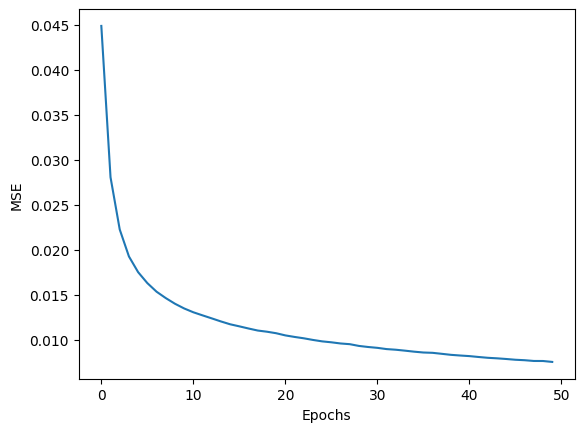

In [31]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.show()

## Visualizing Training and Validation Accuracy

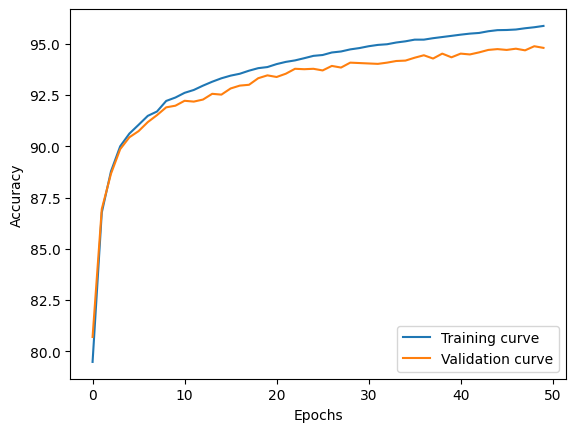

In [32]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc, label='Training curve')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label='Validation curve')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.show()

## Evaluating on the Test Dataset


In [35]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.4f}%')

Test accuracy: 95.2700%


## Examining Misclassified Images

In [36]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]
_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)
misclassified_images = X_test_subset[y_test_subset!=test_pred][:25]
misclassified_labels = test_pred[y_test_subset!=test_pred][:25]
correct_labels = y_test_subset[y_test_subset!=test_pred][:25]

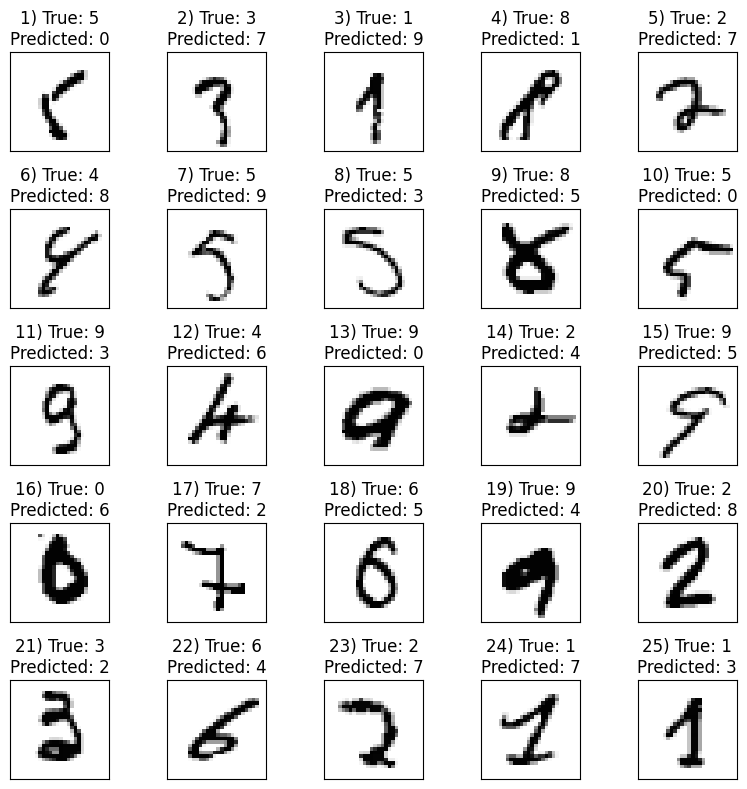

In [40]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
  img = misclassified_images[i].reshape(28, 28)
  ax[i].imshow(img, cmap='Greys', interpolation='nearest')
  ax[i].set_title(f'{i+1}) '
                  f'True: {correct_labels[i]}\n'
                  f'Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()